## Datenvorbereitung

### Daten analysieren

In [1]:
import pandas as pd

# Datenvorbereitung
df = pd.read_csv("Telco-Customer-Churn.csv", sep=",", encoding="utf-8")

has_missing = df.isnull().sum().any() #ueberprueft, ob fehlende werte vorhanden sind
print("Sind fehlende Werte vorhanden?", has_missing)

churn_sum = (df["Churn"] == "Yes").sum()
print("Number of Churn: ", churn_sum)
non_churn_sum = (df["Churn"] == "No").sum()
print("Number of Non-Churn: ", non_churn_sum)

Sind fehlende Werte vorhanden? False
Number of Churn:  1869
Number of Non-Churn:  5174


In [2]:
# Kategorien überprüfen:
for col in df:
    df_content = df[col].unique()
    print(str(col)+": "+str(df_content))

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)

### Daten aufbereiten (geeignet kodieren)

In [3]:
# Daten aufbereiten
categorical_columns = [
    'gender', 
    'Partner', 
    'Dependents', 
    'PhoneService', 
    'MultipleLines', 
    'InternetService', 
    'OnlineSecurity', 
    'OnlineBackup', 
    'DeviceProtection', 
    'TechSupport', 
    'StreamingTV', 
    'StreamingMovies', 
    'Contract', 
    'PaperlessBilling', 
    'PaymentMethod'
]

# Neuen DataFrame erstellen, wobei alle kategorischen Spalten one hot encoded werden
cleaned_df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Customer ID entfernen, weil diese nicht benötigt wird
cleaned_df = cleaned_df.drop(columns="customerID")

# Daten in Floats umwandeln
cleaned_df['TotalCharges'] = pd.to_numeric(cleaned_df['TotalCharges'], errors='coerce')
cleaned_df['MonthlyCharges'] = pd.to_numeric(cleaned_df['MonthlyCharges'], errors='coerce')

## Erstellung des Entscheidungsbaums

### Modelltraining

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

X = cleaned_df.drop(columns="Churn")
y = cleaned_df["Churn"].map({'Yes': 'True', 'No': 'False'})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
decision_tree.fit(X=X_train, y=y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Modellvisualisierung

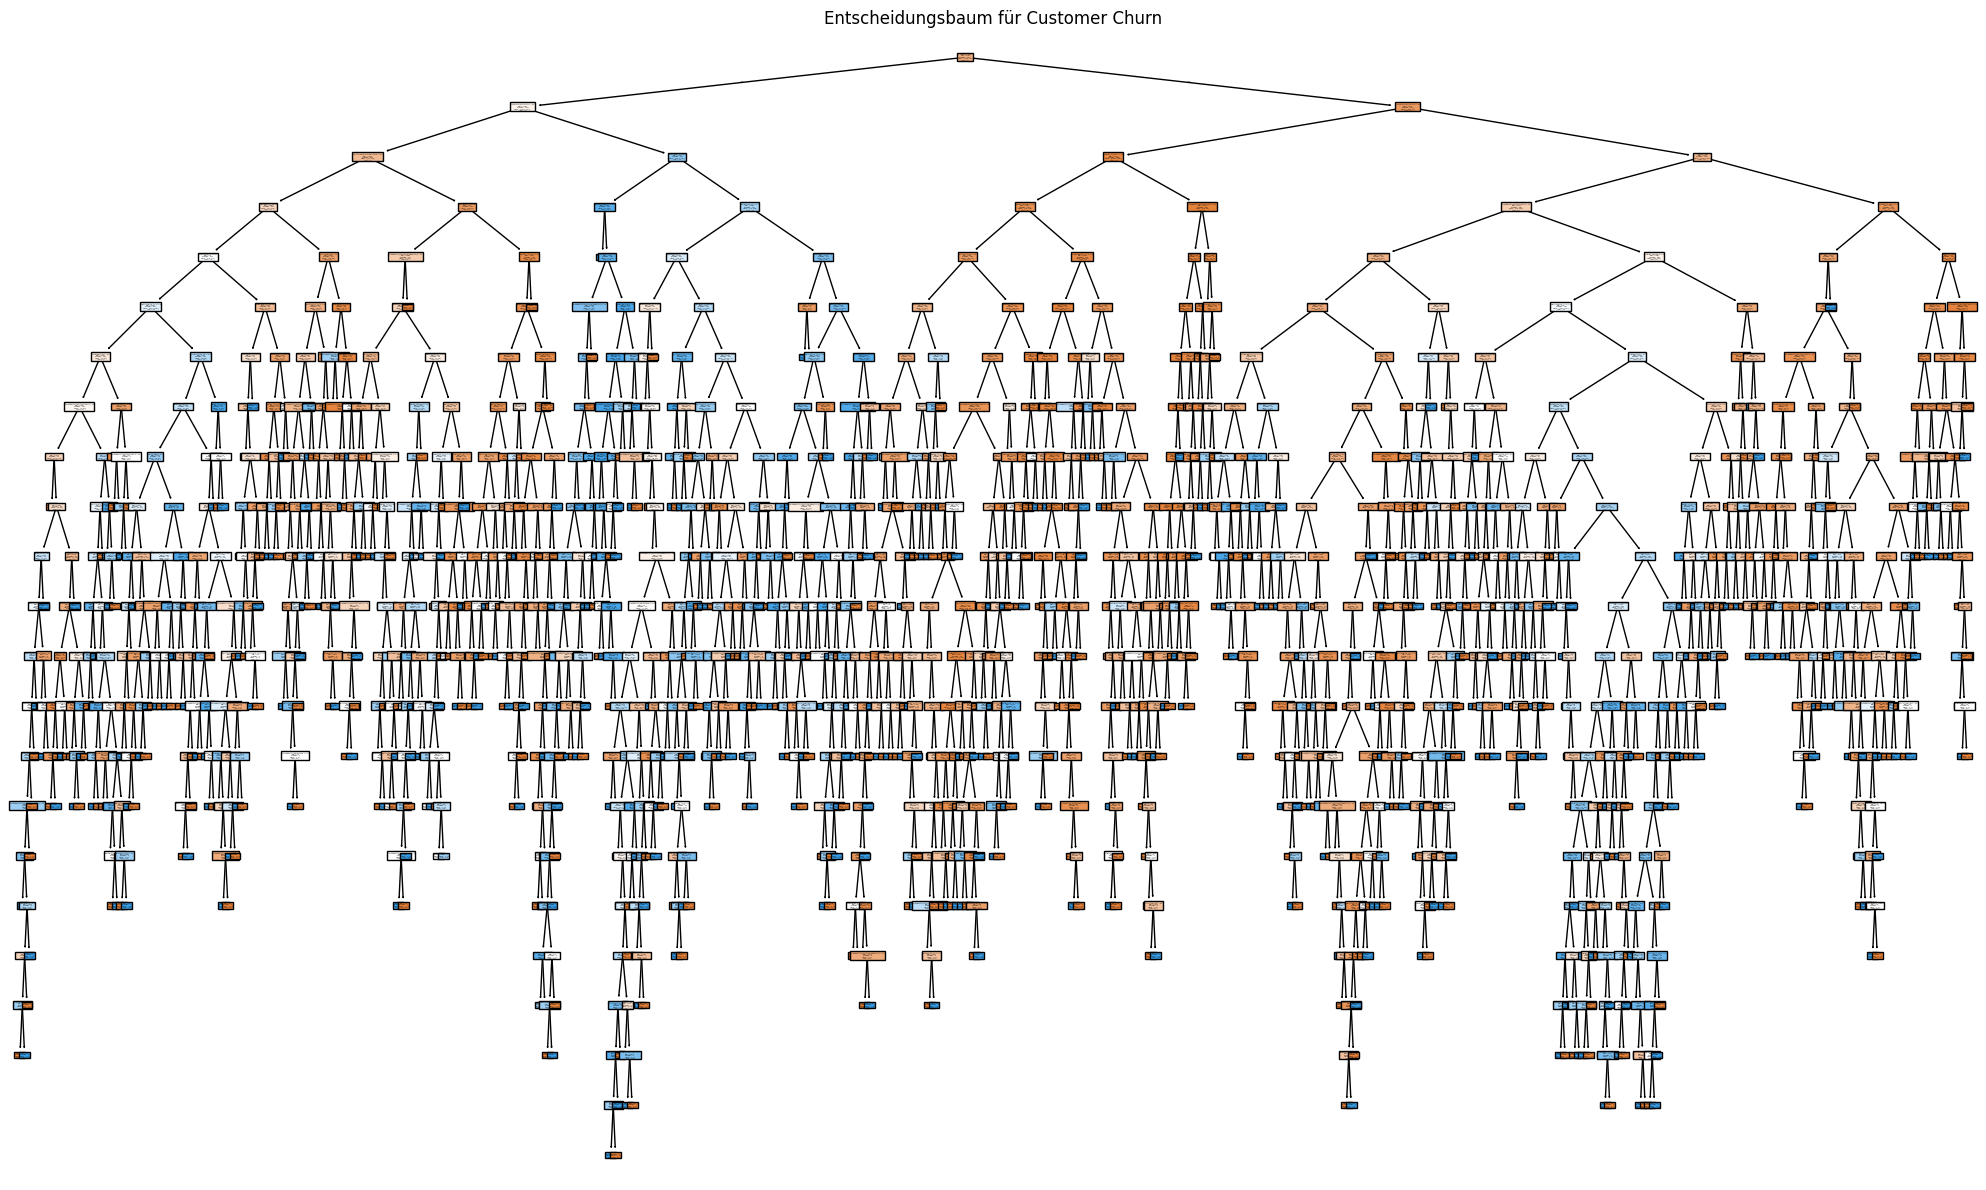

In [56]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 12), dpi=100)

plot_tree(
    decision_tree,                  # Decision Tree
    feature_names=X.columns,        # Namen der Eingabe‑Features
    class_names=["No", "Yes"],      # Zielklassen
    filled=True,                    # farbige Knoten
    impurity=True,                  # Gini‑Impurity anzeigen
)

plt.title("Entscheidungsbaum für Customer Churn")
plt.tight_layout() #Layout des Entscheidungsbaumes verbessern
plt.show()

## Modellbewertung

### Leistungsmetriken

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = decision_tree.predict(X_test)

# Genauigkeit
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print("Genauigkeit: " + str(accuracy))

# Praezsision
precision = precision_score(y_true=y_test, y_pred=y_pred, pos_label='True')
print("Präzision: " + str(precision))

# Recall
recall = recall_score(y_true=y_test, y_pred=y_pred, pos_label='True')
print("Recall: " + str(recall))

# F1-Score
f1 = f1_score(y_true=y_test, y_pred=y_pred, pos_label='True')
print("F1-Score: " + str(f1))

Genauigkeit: 0.738760056791292
Präzision: 0.519298245614035
Recall: 0.5156794425087108
F1-Score: 0.5174825174825175


[[1265  274]
 [ 278  296]]


Text(0.5, 1.0, 'Confusion matrix')

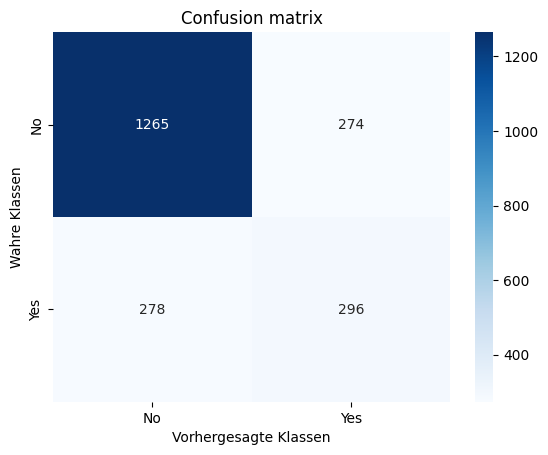

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cf_matrix = confusion_matrix(y_test, y_pred)
print(cf_matrix)

sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes']) #Confusion Matrix mit Seaborn ausgeben
plt.xlabel("Vorhergesagte Klassen")
plt.ylabel("Wahre Klassen")
plt.title("Confusion matrix")

- Wir verpassen genauso viele Kunden, wie wir auffangen wir haben einen unballancierten datensatz

## Optimierung des Modells

### Hyperparameter-Tuning

In [91]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(criterion="gini", random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
)

grid_search.fit(X_train, y_train)
print("Beste Parameter: ", grid_search.best_params_)
print("Beste Genauigkeit: " + str(grid_search.best_score_))

Beste Parameter:  {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Beste Genauigkeit: 0.7886409736308316


## Interpretation und Feature Importance

### Feature Importance

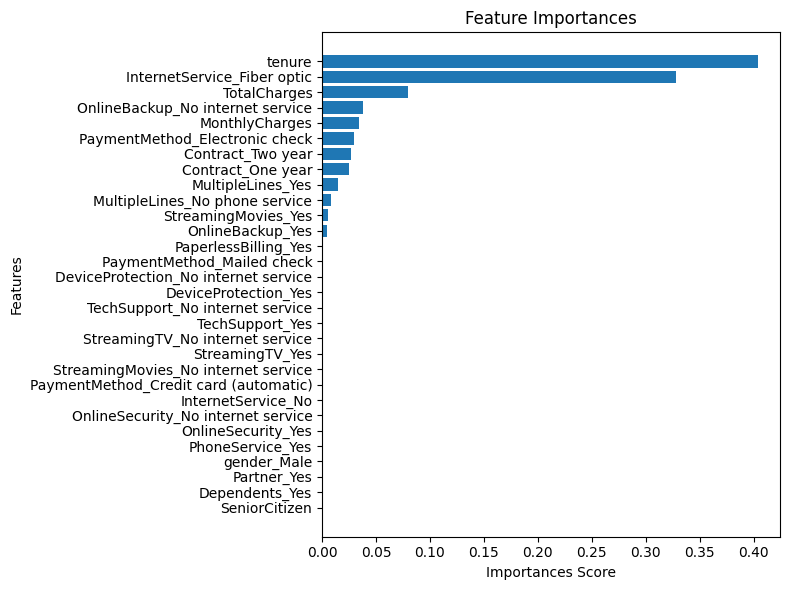

In [92]:
from matplotlib import pyplot as plt
import numpy as np

best_tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=2,criterion="gini",random_state=42)
best_tree = best_tree.fit(X=X_train, y=y_train)

# Feature Namen extrahieren
feature_names = X_train.columns.tolist()

# Indexe sortieren (wichtigstes Feature zuerst)
sorted_idx = np.argsort(best_tree.feature_importances_)[::-1]

# Sortierte Werte und Labels
sorted_importances = best_tree.feature_importances_[sorted_idx]
sorted_features = np.array(feature_names)[sorted_idx]

# Visualisierung der Feature-Wichtigkeiten
plt.figure(figsize=(8,6))
plt.barh(range(len(sorted_importances)), sorted_importances, tick_label=sorted_features)
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.xlabel("Importances Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()